In [1]:
import os
import joblib
import pickle
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams, cycler
from matplotlib.cm import ScalarMappable
import seaborn as sns
import tensorflow as tf
from scipy.stats import pearsonr, gaussian_kde, ecdf, kruskal, friedmanchisquare
from sklearn.decomposition import PCA
import sys
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc11 import *

In [2]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [3]:
v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [4]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01,0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

## Optimization results

In [5]:
P = joblib.load(
    os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'best_permutation.pkl')
)

In [6]:
modfile = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'sgcc_mop_4_18_26.pkl')
with open(modfile, 'rb') as f:
    optimized_model = pickle.load(f)

In [7]:
sgcc = SGCCircuit(param_bounds, enforce_permutation=P[:1])
p = {
    'dLGN_params': optimized_model['final_epoch_params']['dLGN_params'].std(0)[None],
    'V1_params': optimized_model['final_epoch_params']['V1_params'].std(0)[None]
}

sgcc.load_saved_parameters(p)
sgcc.update_transform()

In [8]:
e_dlgn = sgcc.params['dLGN_params'].numpy()[0,:,:,:,0,0].astype(np.float64)
e_v1 = sgcc.params['V1_params'].numpy()[0,:,:,:,0,0].astype(np.float32)

In [9]:
sgcc = SGCCircuit(param_bounds, enforce_permutation=P[:1])
p = {
    'dLGN_params': optimized_model['final_epoch_params']['dLGN_params'].mean(0)[None],
    'V1_params': optimized_model['final_epoch_params']['V1_params'].mean(0)[None]
}

sgcc.load_saved_parameters(p)
sgcc.update_transform()

In [10]:
u_dlgn = sgcc.params['dLGN_params'].numpy()[0,:,:,:,0,0].astype(np.float32)
u_v1 = sgcc.params['V1_params'].numpy()[0,:,:,:,0,0].astype(np.float32)

In [11]:
t_u = u_dlgn[:,:,:2]
t_e = e_dlgn[:,:,:2]

a_u = u_dlgn[:,:,2:-1]
a_e = e_dlgn[:,:,2:-1]

In [12]:
def gaussian(
    support, # domain of the function
    ctr, # mean of the function
    mid, # midline of the function
    amp, # amplitude of the function
    std # bandwidth parameter
):

    f = np.exp(-1*(((support-ctr)**2)/(2*std**2)))

    return mid+(amp*f)

def line(support, slope, intercept):
    return slope * support + intercept

In [13]:
x = tf.linspace(0.02, 0.32, 250)
R = sgcc.predict(x)

C:\Users\Sturdy\AppData\Local\Temp\ipykernel_31780\3393062425.py:11: UserWarning: The following kwargs were not used by contour: 'lw'
  ax.contourf(X_, Y, Z, alpha = 0.75, lw=0.5, cmap = 'inferno', offset = 0,)


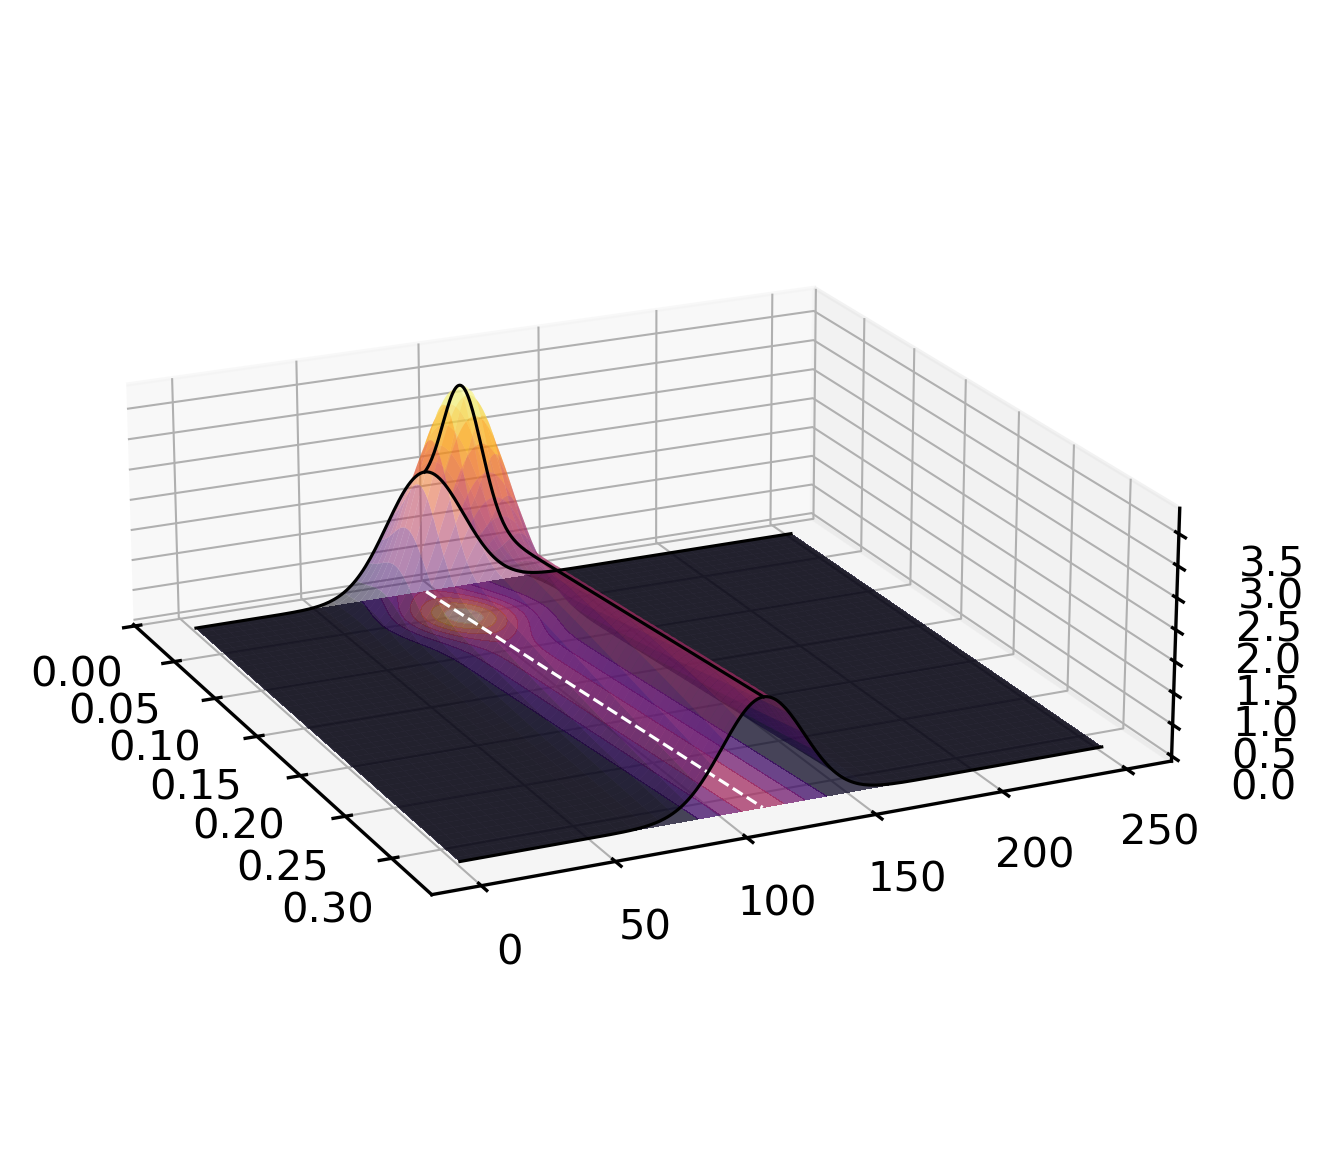

In [14]:
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import axes3d

ax = plt.figure().add_subplot(projection='3d')
y = np.linspace(0,250,250)  # time points
X_,Y = np.meshgrid(x,y)

Z = sgcc.dlgn_exc.numpy()[0,0,0].T
ax.plot_surface(X_, Y, Z, alpha = 0.5, lw=0.5, cmap = 'inferno', zorder = 0)
ax.contourf(X_, Y, Z, alpha = 0.75, lw=0.5, cmap = 'inferno', offset = 0,)
ft_uexp = t_u[:,:,0:1] * np.linspace(0.02,0.32,250) + t_u[:,:,1:]
ax.plot(
    np.linspace(0.02,0.32,250), 
    ft_uexp[0,0],
    gaussian(x, *sgcc.params['dLGN_params'][0,0,0,2:6,0,0]),
    zorder = 10, color = 'black', linewidth = 0.75, linestyle = '-'
)

ax.plot(
    np.full(250, x[0]), 
    y, 
    Z[:,0], '-',
    zorder = 10, color = 'black',
    linewidth = 0.75, 
)


ax.plot(
    np.full(250, x[-1]), 
    y, 
    Z[:,-1], '-',
    zorder = 10, color = 'black',
    linewidth = 0.75
)

ax.plot(x, ft_uexp[0,0], '--', zs=0, zdir='z', color = 'white', linewidth = 0.75, zorder = 5)

ax.xaxis._axinfo['grid'].update({'linewidth': 0.5})
ax.yaxis._axinfo['grid'].update({'linewidth': 0.5})
ax.zaxis._axinfo['grid'].update({'linewidth': 0.5})
ax.set_box_aspect((3, 3, 1)) 
ax.view_init(elev=20, azim=-25)

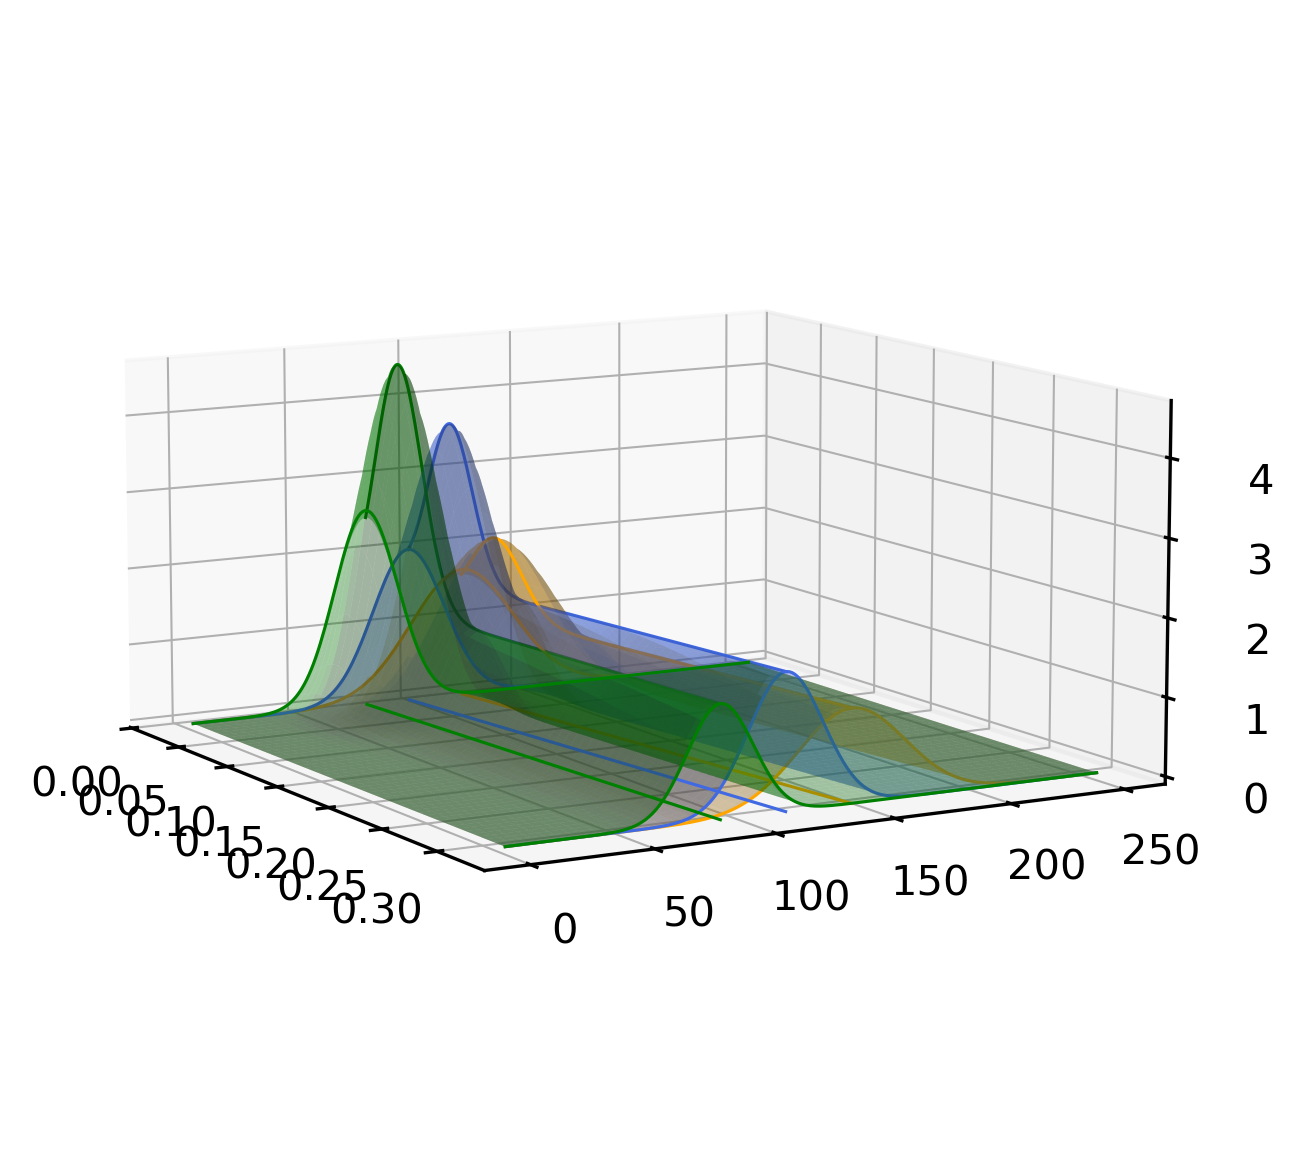

In [15]:
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import axes3d

ax = plt.figure().add_subplot(projection='3d')
y = np.linspace(0,250,250)  # time points
X_,Y = np.meshgrid(x,y)

colors = ['royalblue', 'green', 'orange']
ax.computed_zorder = False
ord = [1,2,0]
for i in range(3):
    Z = sgcc.dlgn_exc.numpy()[0,0,i].T
    ax.plot_surface(X_, Y, Z, alpha = 0.35, lw=0.5, color = colors[i], zorder = ord[i])
    ft_uexp = t_u[:,:,0:1] * np.linspace(0.02,0.32,250) + t_u[:,:,1:]
    ax.plot(
        np.linspace(0.02,0.32,250), 
        ft_uexp[0,i],
        gaussian(x, *sgcc.params['dLGN_params'][0,0,i,2:6,0,0]),
        zorder = 0, color = colors[i], linewidth = 0.75, linestyle = '-'
    )

    ax.plot(
        np.full(250, x[0]), 
        y, 
        Z[:,i], '-',
        zorder = ord[i], color = colors[i],
        linewidth = 0.75, 
    )

    ax.plot(
        np.full(250, x[-1]), 
        y, 
        Z[:,-1], '-',
        zorder = ord[i], color = colors[i],
        linewidth = 0.75
    )

    ax.plot(x, ft_uexp[0,i], '-', zs=0, zdir='z', color = colors[i], linewidth = 0.75, zorder = ord[i])
ax.xaxis._axinfo['grid'].update({'linewidth': 0.5})
ax.yaxis._axinfo['grid'].update({'linewidth': 0.5})
ax.zaxis._axinfo['grid'].update({'linewidth': 0.5})
ax.set_box_aspect((2, 2, 1)) 

ax.view_init(elev=10, azim=-30)

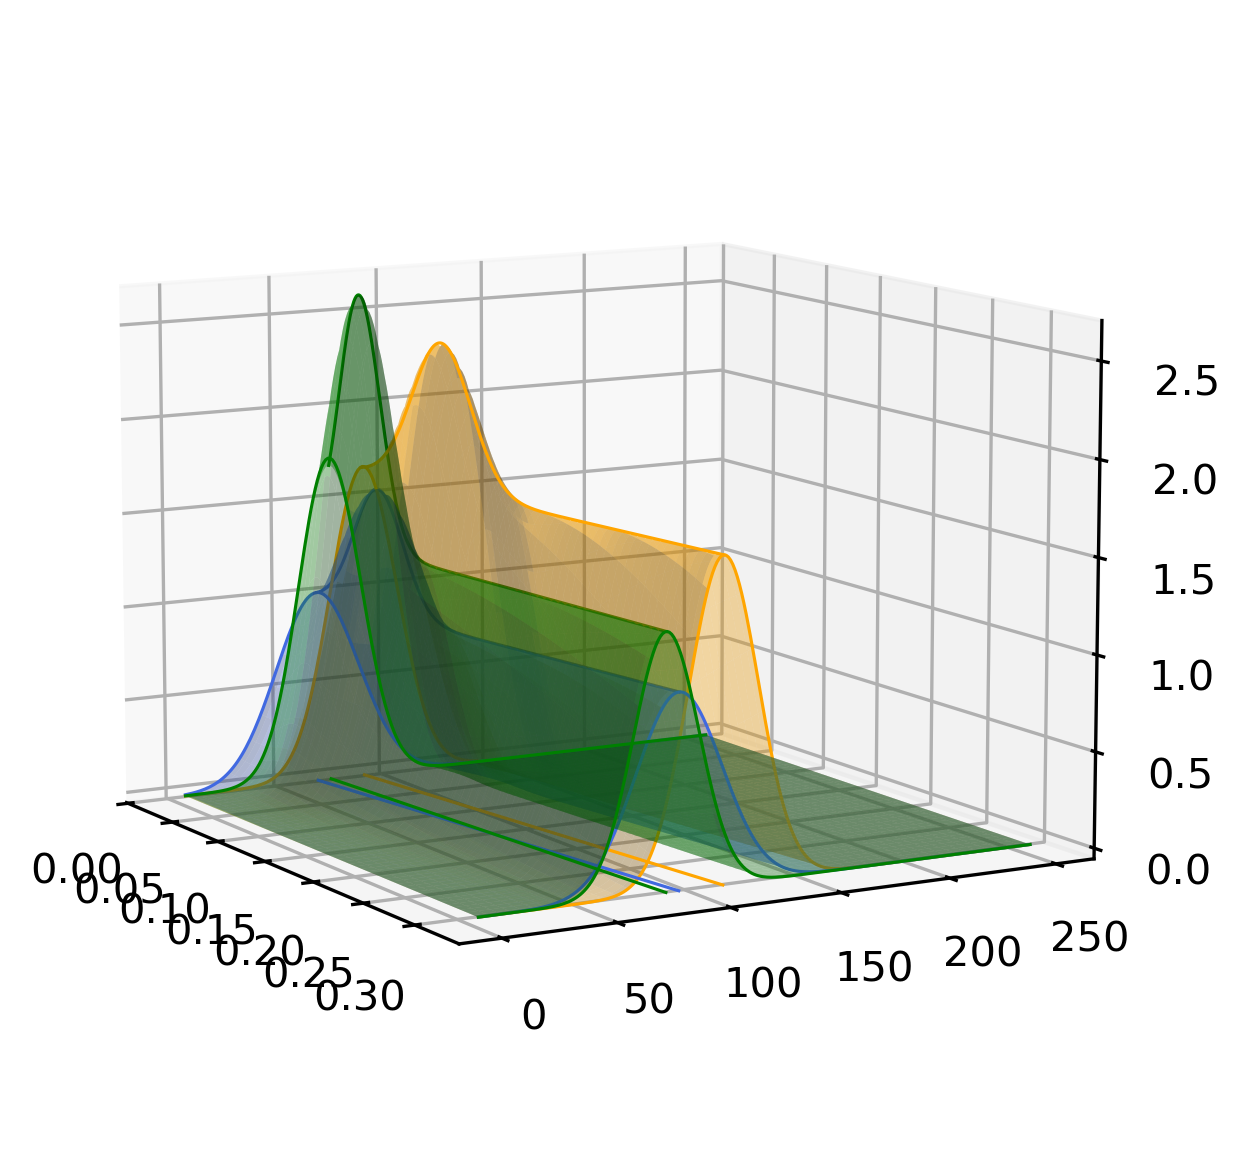

In [16]:
import matplotlib.pyplot as plt

from mpl_toolkits.mplot3d import axes3d

ax = plt.figure().add_subplot(projection='3d')
y = np.linspace(0,250,250)  # time points
X_,Y = np.meshgrid(x,y)

colors = ['royalblue', 'green', 'orange']
ax.computed_zorder = False
ord = [1,2,0]
for i in range(3):
    Z = sgcc.dlgn_exc.numpy()[0,1,i].T
    ax.plot_surface(X_, Y, Z, alpha = 0.35, lw=0.5, color = colors[i], zorder = ord[i])
    ft_uexp = t_u[:,:,0:1] * np.linspace(0.02,0.32,250) + t_u[:,:,1:]
    ax.plot(
        np.linspace(0.02,0.32,250), 
        ft_uexp[1,i],
        gaussian(x, *sgcc.params['dLGN_params'][0,1,i,2:6,0,0]),
        zorder = 0, color = colors[i], linewidth = 0.75, linestyle = '-'
    )

    ax.plot(
        np.full(250, x[0]), 
        y, 
        Z[:,i], '-',
        zorder = ord[i], color = colors[i],
        linewidth = 0.75, 
    )

    ax.plot(
        np.full(250, x[-1]), 
        y, 
        Z[:,-1], '-',
        zorder = ord[i], color = colors[i],
        linewidth = 0.75
    )

    ax.plot(x, ft_uexp[1,i], '-', zs=0, zdir='z', color = colors[i], linewidth = 0.75, zorder = ord[i])


ax.view_init(elev=10, azim=-30)